In [61]:
import otter
grader = otter.Notebook()

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# DSCI 311 Fall 25 Midterm
## Due Date: Thursday 10/30 by 11:59 PM PST

**Collaboration Policy: No collaboration is allowed on this test. All work must be your own.**

**AI Policy**: You may use AI (and other internet resources) to *help* you answer questions. You may not copy any code wholesale from AI output. Consider AI as an informative assistant, *not* as a replacement for you (on this exam and in life). If I suspect purely AI-generated code, I'll ask you about it and expect you to explain clearly why you coded things in that way.

- An appropriate AI query: "I need to make this dataset longer but can't figure out the argument for turning columns into values. Can you help me understand the function?"

- An invalid AI query: "Give me code to make these data longer."

**Note that for ALL plotting questions, we will expect appropriate titles, axis labels, legends, etc. The following question serves as a good guideline on what is "enough": If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question?** 

This midterm may cover any topics through the first 4 weeks of class. You may be expected to do things that we have not explicitly shown in class or in an assignment - this is intentional, and why we expect you to reference function documentation (*e.g.* `help(pd.read_csv)`) or internet resources for help. But most of what you will do will have been shown either in lecture (in slides or in lecture notebooks) or in assignments. 

There are three sections to the midterm:

**Section 1**: Candy 

**Section 2**: Horror movies

**Section 3**: Hauntings

**Grader Tests**: As in homeworks, these tests only check whether your answer *could* be correct, not whether it is correct. 

## Section 1

Here we'll be reading in two datasets describing halloween candy - `candy_qualities.csv`, which contains traits associated with various halloween candies, and `candy_rankings.csv` which contains ranked preferences for each candy and a few additional characteristics as surveyed in 2017 with 269,000 votes. Our objective is simple: **determine the ultimate halloween candies and their characteristics**. The first step in this process will be to combine our data.

`candy_qualities.csv`:
    
    `name` - the name of the candy
    `quality` - some quality that may or may not represent the candy
    `value` - whether or not candy has the associated quality 

    Note that the quality 'pluribus' means candy that comes in multiples (think Skittles)
    
`candy_rankings.csv`: 

    `competitorname` - the name of the candy
    `sugarpercent` - the percentile of sugar it falls under in the data set
    `pricepercent` - the unit price percentile compared to the rest of the data set
    `winpercent` - the overall win percentage based on 269,000 matchups. 

Read in `candy_qualities.csv` and `candy_rankings.csv`.

In [63]:
candy_quals = pd.read_csv("data/candy_qualities.csv")

In [64]:
candy_quals.head()

,name,quality,value
0,100 Grand,chocolate,1
1,3 Musketeers,chocolate,1
2,One dime,chocolate,0
3,One quarter,chocolate,0
4,Air Heads,chocolate,0


In [65]:
candy_rankings = pd.read_csv("data/candy_rankings.csv")

In [66]:
candy_rankings.head()

,competitorname,sugarpercent,pricepercent,winpercent
0,100 Grand,0.732,0.860,66.971725
1,3 Musketeers,0.604,0.511,67.602936
2,One dime,0.011,0.116,32.261086
3,One quarter,0.011,0.511,46.116505
4,Air Heads,0.906,0.511,52.341465


#### Question 1

Our goal is to merge our two datasets together without duplicating any records. We therefore need to first format our datasets similarily. Pivot `candy_quals` so that there is only a **single record** (row) per candy. In other words, the granularity of the data should be at the level of candy name.

In [67]:
candy_wide = pd.pivot(candy_quals, index='name', columns='quality', values='value').reset_index()
candy_wide

quality,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus
0,100 Grand,1,1,1,1,0,0,0,0,0
1,3 Musketeers,1,0,1,0,0,0,1,0,0
2,Air Heads,0,0,0,0,1,0,0,0,0
3,Almond Joy,1,0,1,0,0,0,0,1,0
4,Baby Ruth,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,0,0,0,1,0,0,0,0
81,Warheads,0,0,0,0,1,1,0,0,0
82,WelchÕs Fruit Snacks,0,0,0,0,1,0,0,0,1
83,WertherÕs Original Caramel,0,1,0,0,0,1,0,0,0


In [68]:
grader.check("q1_1")

q1_1 results: All test cases passed!

#### Question 2

To combine our two datasets, we need to canonicalize their keys. Identify all of the candy names in `candy_wide` that aren't matches in `candy_rankings`, returned as a Series or a numpy array.

In [69]:
mismatches = np.setdiff1d(list(candy_wide.index), list(candy_rankings['competitorname']))
mismatches

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84])

In [70]:
grader.check("q1_2")

q1_2 results: All test cases passed!

#### Question 3

Fix the issues in the key of `candy_wide` so that we can successfully merge our data (*i.e.* make these non-matching values match their counterparts in `candy_rankings`). 

In [71]:
candy_wide["name"] = candy_wide["name"].str.replace('Õ', '')

In [72]:
grader.check("q1_3")

q1_3 results: All test cases passed!

#### Question 4

Finally, merge the two Dataframes such that no information is lost in either frame. 

In [73]:
candy = pd.merge(candy_wide, candy_rankings, left_on=['name'], right_on=['competitorname'], how='inner').drop('competitorname', axis=1)
candy.head()

,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,1,1,1,0,0,0,0,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,1,0,0,0,1,0,0,0.604,0.511,67.602936
2,Air Heads,0,0,0,0,1,0,0,0,0,0.906,0.511,52.341465
3,Almond Joy,1,0,1,0,0,0,0,1,0,0.465,0.767,50.347546
4,Baby Ruth,1,1,1,0,0,0,1,1,0,0.604,0.767,56.914547


In [74]:
grader.check("q1_4")

q1_4 results: All test cases passed!

#### Question 5

Plot the associations with regression lines between sugar % and win %, and price % and win %. Plot both associations on the same figure and ensure that each has a different color. Include a legend labeling each color. 

You can use any method you want for the regression lines, either estimating them manually or using seaborn's plotting functions. 

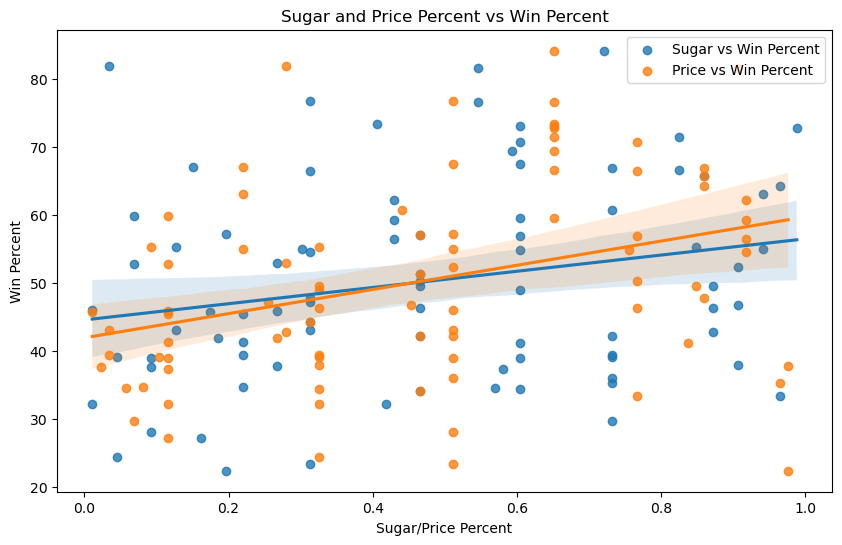

In [75]:
fig, ax = plt.subplots(figsize=(10,6))
sns.regplot(data=candy, x='sugarpercent', y='winpercent', ax=ax, label='Sugar vs Win Percent')
sns.regplot(data=candy, x='pricepercent', y='winpercent', ax=ax, label='Price vs Win Percent')
ax.legend()
plt.title("Sugar and Price Percent vs Win Percent")
plt.xlabel("Sugar/Price Percent")
plt.ylabel("Win Percent")
plt.show()
#Aren't these proportions?

#### Question 6

What can we infer about more popular candy from the above plot?

**Your response**: Candy with higher win percentages tend to have higher price and sugar percentages, i.e. are more expensive and sweeter based on the positive slopes of the regression lines in the plot above. The price of a candy being higher seems to have a slightly greater association with higher win percentages than it having a high sugar percentage. 

#### Question 7

Create a **horizontal** barplot representing the sums of each candy quality. Ensure the barplot is sorted from most to least.  

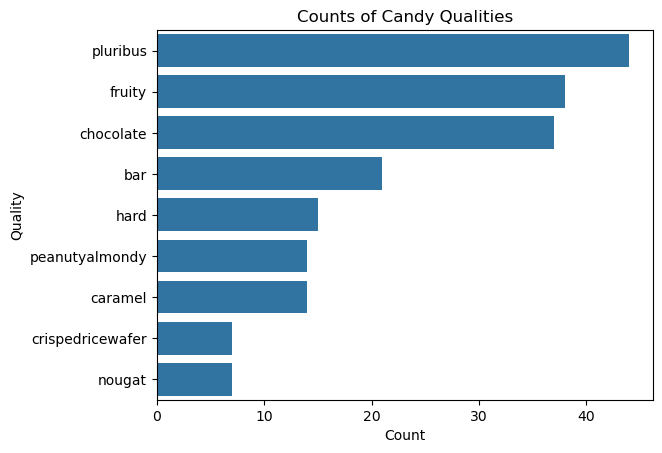

In [76]:
sum_quals = candy_quals.query("value > 0").groupby('quality').agg(
    total=('quality', 'count')
).sort_values("total", ascending=False)

sns.barplot(data=sum_quals, x='total', y='quality')
plt.title("Counts of Candy Qualities")
plt.xlabel("Count")
plt.ylabel("Quality")
plt.show()

#### Question 8

Now split the data into two subsets: the 50% of candy above the median of win percent and the 50% of candy below the median. Then plot a **paired**, horizontal barplot representing the same counts of each quality as above, where black bars represent the less popular candy and orange bars represent the more popular candy. 

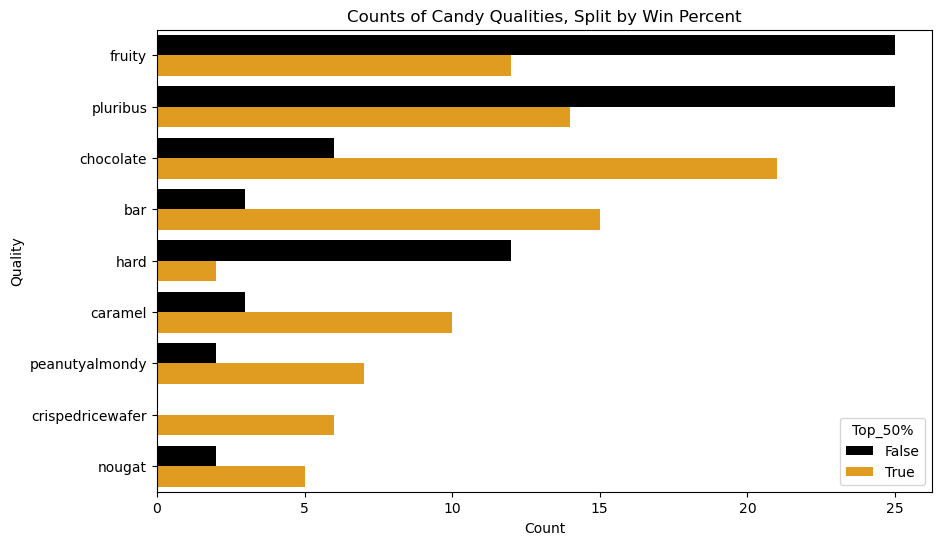

In [77]:
candy["Top_50%"] = candy["winpercent"] > np.median(candy["winpercent"])

merged = pd.merge(candy_quals, candy[["name", "Top_50%"]], on='name')

sum_quals_split = merged.query("value > 0").groupby(['quality', 'Top_50%']).agg(
    total=('quality', 'count')
).sort_values("total", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=sum_quals_split, x='total', y='quality', hue='Top_50%', palette=['black', 'orange'])
plt.title("Counts of Candy Qualities, Split by Win Percent")
plt.xlabel("Count")
plt.ylabel("Quality")
plt.show()

#### Question 9

Characterize the most popular and the least popular halloween candy, giving extra emphasis to how they differ.

**Your response**: Measured by win percentage, most popular halloween candies tend to have more sugar and cost more than their less popular counterparts, though the correlation isn't very strong due to the wide spread of datapoints around the regression lines for each variable. Analyzed by their qualities, popular and less popular halloween candies differ greatly depending on their general characteristics. Most popular halloween candies tend to be bars, with chocolate, nougat, caramel, nutes, and crisped rice wafer (the last quality being the strongest associated, with all candies containing crisped rice wafers being more popular in the data). Less popular halloween candies tend to be hard candies with fruity flavors and coming in multiples in a pack. 

## Section 2

Read in the `IMDB Horror Movies` dataset. This dataset represents a subset of some of the best-know movies in the horror genre released between 1920 and 2023.  

In [78]:
horror = pd.read_csv("data/Horror Movies IMDB.csv")
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M
4,Tumbbad,2018,104,"Drama, Fantasy, Horror",8.2,Rahi Anil Barve,"53,297",NaN


#### Question 1

`Gross` represents the total amount each movie grossed in theatres in millions.

What type of variable does `Gross` represent? Based on your answer, what issues are there in the current formatting of the variable? 

**Your response**: Gross represents total money earned at the box office, so it's a continuous quantitative variable. Therefore, the inclusion of dollar signs and 'M' in the current formatting will make analysis difficult, as they are not integers or floats right now.

#### Question 2

Clean a variable `Gross_clean` such that it is now the type of variable you identified above and can be used for analyses. We don't want to look at movies that didn't make any money, so also filter the data for values of `Gross_clean` greater than 0. 

In [79]:
horror["Gross_clean"] = horror["Gross"].str.replace(r'[^0-9.]', '', regex=True).astype(float)
horror = horror.query("Gross_clean > 0")
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91


In [80]:
grader.check("q2_2")

q2_2 results: All test cases passed!

#### Question 3

First create a subset of the data filtering out NA values in `Gross_clean`. 

Then visualize the distributions of `Gross_clean` and `Rating`. Apply any tansformations to the data (if necessary) to make both variables approximately normally distributed. It's fine if there is still some tail to the distribution.

In [81]:
horror = horror.dropna(subset=['Gross_clean'])
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91


Text(0.5, 1.0, 'Distribution of Gross Earnings for Horror Movies')

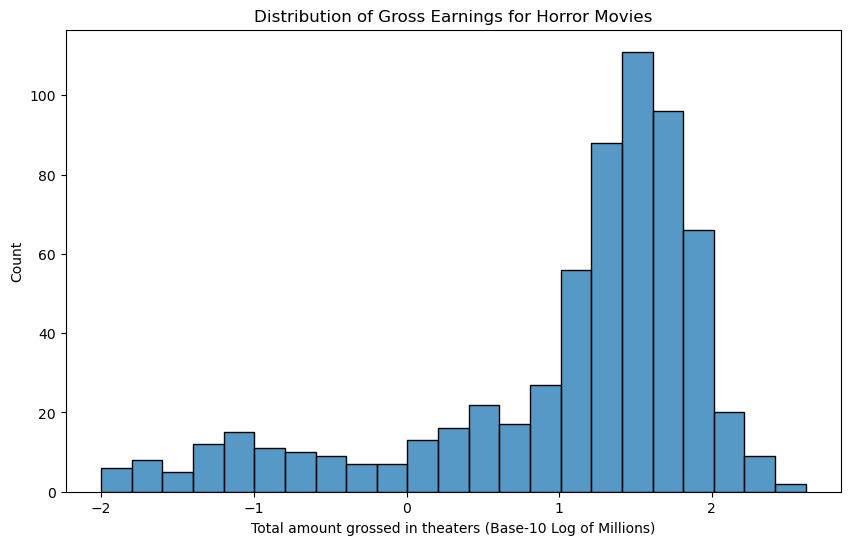

In [82]:
plt.figure(figsize=(10,6))
sns.histplot(x=horror['Gross_clean'].apply(np.log10))
plt.xlabel('Total amount grossed in theaters (Base-10 Log of Millions)')
plt.ylabel('Count')
plt.title('Distribution of Gross Earnings for Horror Movies')

Text(0.5, 1.0, 'Distribution of IMDB ratings of horror movies')

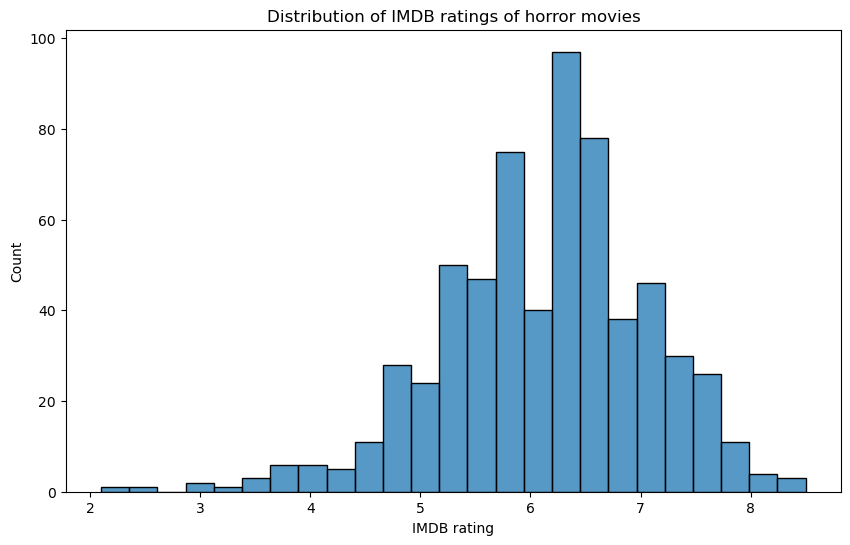

In [83]:
plt.figure(figsize=(10,6))
sns.histplot(data=horror, x='Rating')
plt.xlabel('IMDB rating')
plt.ylabel('Count')
plt.title('Distribution of IMDB ratings of horror movies')

#### Question 4

One of the presumed characteristics of "oscar bait" i.e. films gunning for awards is a long runtime. Is there any evidence for this among horror movies? Evaluate this visually with a regression plot for each of the transformed and untransformed rating. 

Text(0.5, 1.0, 'Runtime vs cubed IMDB rating of horror movies')

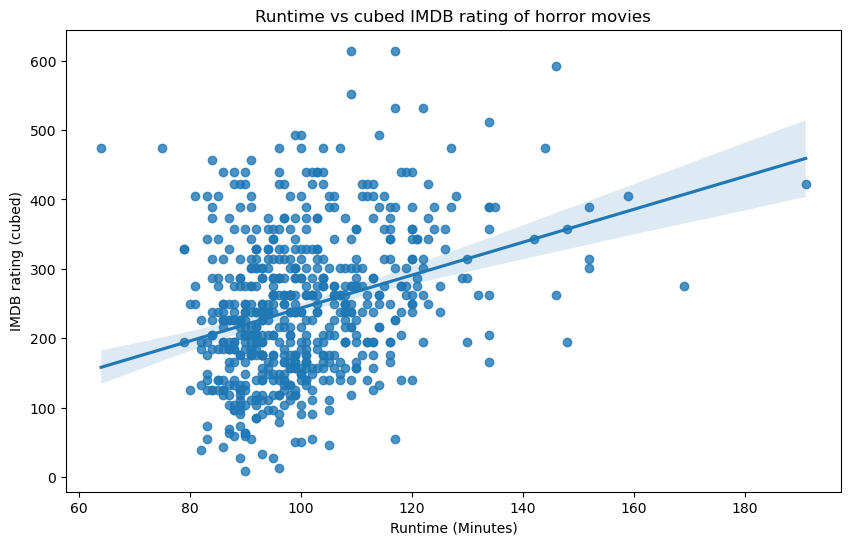

In [84]:
plt.figure(figsize=(10,6))
sns.regplot(x=horror['Runtime'], y=horror['Rating'].apply(lambda x: x**3))
plt.xlabel('Runtime (Minutes)')
plt.ylabel('IMDB rating (cubed)')
plt.title('Runtime vs cubed IMDB rating of horror movies')

Text(0.5, 1.0, 'Runtime vs IMDB rating of horror movies')

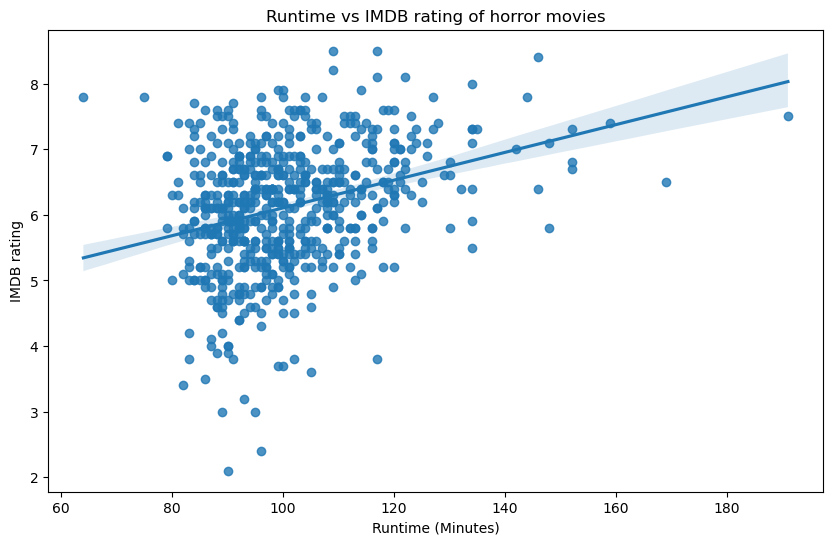

In [85]:
plt.figure(figsize=(10,6))
sns.regplot(data=horror, x='Runtime', y='Rating')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('IMDB rating')
plt.title('Runtime vs IMDB rating of horror movies')

#### Question 5

What do you conclude from the above visualization? Describe the association, and whether you think a simple linear model is an effective description of the relationship.

**Your response**: From the visualizaitons, there seems to be a positive correlation between runtime and rating, where an increase in runtime corresponds to an increase in rating. I am skeptical this is a good way to describe the relationship, however. There's no consideration for other variables, and there's very few data points for ratings below 5 or above 8, limiting the validity of the conjecture. Similarly, there's very few films longer than 120 minutes compared to the size of the entire sample. 

#### Question 6

Who are the 5 most highly rated directors (on average) **among directors with at least 3 movies in the data**? Return your answer as a Series or numpy array.

In [86]:
df = horror.groupby("Director").agg(
    Movie_count=("Director", "count"),
    Avg_rating=("Rating", "mean")
).query("Movie_count >= 3").reset_index()
best_directors = np.array(df.nlargest(5, 'Avg_rating')["Director"])
best_directors

array(['Jordan Peele', 'David Cronenberg', 'Sam Raimi',
       'Robert Rodriguez', 'James Wan'], dtype=object)

In [87]:
grader.check("q2_6")

q2_6 results: All test cases passed!

#### Question 8

Create three new columns in `horror` called `Primary Genre`, `Secondary Genre` and `Tertiary Genre`. These columns should be populated by the values in Genre in the order they appear. For example, the movie Alien should have "Horror" as its primary genre, "Sci-Fi" as its secondary genre, and "None" as its tertiary genre.

*Hint* You may want to review your string methods here.

In [88]:
horror[['Primary Genre', 'Secondary Genre', 'Tertiary Genre']] = (
    horror['Genre'].str.split(', ', expand=True)
)
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90,Horror,Sci-Fi,None
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00,Horror,Mystery,Thriller
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02,Drama,Horror,None
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78,Horror,Mystery,Sci-Fi
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91,Horror,None,None


In [89]:
grader.check("q2_8")

q2_8 results: All test cases passed!

#### Question 9

All of the movies in the dataset are horror movies, so the inclusion of Horror as a genre isn't helpful. Create a new column called `Genre_clean` that represents either the primary genre of the movie, or the secondary genre if the primary genre of the movie is "Horror". There should therefore be no value of "Horror" in `Genre_clean`. 

For example, `Genre_clean` for Alien should be 'Sci-Fi', 'Mystery' for Psycho, and 'Drama' for The Shining.

In [90]:
horror["Genre_clean"] = np.where(
    horror["Primary Genre"] != "Horror",
    horror["Primary Genre"],
    horror["Secondary Genre"]
)
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre,Genre_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78.90,Horror,Sci-Fi,None,Sci-Fi
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32.00,Horror,Mystery,Thriller,Mystery
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44.02,Drama,Horror,None,Drama
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13.78,Horror,Mystery,Sci-Fi,Mystery
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232.91,Horror,None,None,None


In [91]:
grader.check("q2_9")

q2_9 results: All test cases passed!

#### Question 10

Have horror movies gotten better or worse through time? Visually evaluate this with a paired boxplot of ratings for the 3 most popular genres (genres with the highest incidence in the data) before and after the year 2000 (inclusive in either direction). 

Text(0.5, 1.0, 'Genre vs IMDB rating of horror movies before and after 2000 for 3 most frequent subgenres')

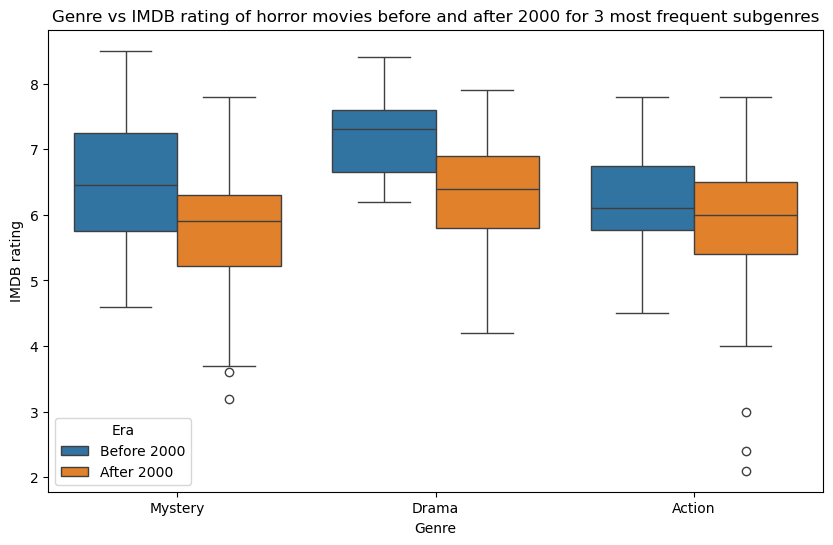

In [92]:
horror["Era"] = np.where(
    horror["Movie Year"] < 2000,
    "Before 2000",
    "After 2000"
)
horror["Top_Genres"] = horror["Genre_clean"].isin(horror["Genre_clean"].value_counts()[:3].index.tolist())
most_freq = horror.query("Top_Genres == True")

plt.figure(figsize=(10,6))
sns.boxplot(data=most_freq, x='Genre_clean', y='Rating', hue='Era')
plt.xlabel('Genre')
plt.ylabel('IMDB rating')
plt.title('Genre vs IMDB rating of horror movies before and after 2000 for 3 most frequent subgenres')

## Section 3

Read in the `haunted_places` dataset. This is a dataset of all known haunting in the U.S. and associated descriptions. Each record is associated with one haunting. 

In [93]:
hauntings = pd.read_csv("data/haunted_places.csv")
hauntings.head()

,city,country,description,location,state,state_abbrev,longitude,latitude,city_longitude,city_latitude
0,Ada,United States,Ada witch - Sometimes you can see a misty blue...,Ada Cemetery,Michigan,MI,-85.504893,42.962106,-85.495480,42.960727
1,Addison,United States,A little girl was killed suddenly while waitin...,North Adams Rd.,Michigan,MI,-84.381843,41.971425,-84.347168,41.986434
2,Adrian,United States,If you take Gorman Rd. west towards Sand Creek...,Ghost Trestle,Michigan,MI,-84.035656,41.904538,-84.037166,41.897547
3,Adrian,United States,"In the 1970's, one room, room 211, in the old ...",Siena Heights University,Michigan,MI,-84.017565,41.905712,-84.037166,41.897547
4,Albion,United States,Kappa Delta Sorority - The Kappa Delta Sororit...,Albion College,Michigan,MI,-84.745177,42.244006,-84.753030,42.243097


#### Question 1

Read in the `state_populations` file and use it (with `haunted_places`) to determine which state has the most hauntings *per capita* in the United States (hauntings per individual). Return your answer as a string. 

In [94]:
pop = pd.read_csv("data/state_populations.csv")

In [95]:
haunt_counts = hauntings.groupby("state").agg(
    Count=("state", "count")
).reset_index().merge(pop, on="state")

haunt_counts["Per_capita"] = haunt_counts["Count"] / haunt_counts["population"]
print(haunt_counts[haunt_counts["Per_capita"] == haunt_counts["Per_capita"].max()]["state"])

most_haunted = "Wyoming"
most_haunted

49    Wyoming
Name: state, dtype: object


'Wyoming'

In [96]:
grader.check("q3_1")

q3_1 results: All test cases passed!

#### Question 2

The ratios of females to males in the U.S. is roughly 49/51 (or about 0.96). One would presume that hauntings reflect a similar sex ratio. 

What ratio of hauntings involve a girl versus a boy ($\frac{girl}{boy}$) and what ratio involve a woman versus a man ($\frac{woman}{man}$)?

In [97]:
girl_boy_ratio = sum(hauntings['description'].str.contains(' girl ')) / sum(hauntings['description'].str.contains(' boy '))
girl_boy_ratio

2.129343629343629

In [98]:
woman_man_ratio = sum(hauntings['description'].str.contains(' woman ')) / sum(hauntings['description'].str.contains(' man '))
woman_man_ratio

0.7107046070460704

In [99]:
grader.check("q3_2")

q3_2 results: All test cases passed!

Is the ratio similar or different between the two subsets? What can we infer about how age affects the likelihood of different sexes lingering after death?

**Your response** The ratio is very different for girl/boy vs woman/man. The girl/boy ratio is over 2, meaning hauntings involving girls double the number of hauntings involving boys. Meanwhile, the woman/man ratio is 0.71, meaning there's a bit more hauntings involving men than women. We can infer that age affects the likelyhood of different sexes lingering after death; young souls/spirits are overwhelmingly female and older souls/spirits tend to be male but are much more evenly split.

#### Question 3

Create a horizontal barplot of the 20 most common locations in the haunting descriptions. Be sure to lowercase all of the words. The resulting barchart should *only* include general location names (e.g. hospital, cemetary, house), not proper nouns (e.g. the specific name of a hospital), articles (e.g "the", "an", "is" etc...) or adjectives. Multiple words for the same thing is ok (e.g. street and road).

In [100]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"])
ents = Counter()

def split_big(text, chunk_size):
    chunks = []
    for i in range(0, len(text), chunk_size):
        chunks.append(text[i:i+chunk_size])
    return chunks

hauntings["description_clean"] = hauntings["description"].replace("[^a-zA-Z ]", "", regex=True)
text = hauntings['description_clean'].str.cat(sep=' ')
chunks = split_big(text, 500000)

tags = ['LOC', 'FAC']

for chunk in chunks:
    doc = nlp(chunk)
    for token in doc:
        if token.ent_type_ in tags:
            ents[token.text] += 1

In [101]:
freq_places = ents.most_common(31)
idxs = [0, 3, 7, 10, 12, 14, 15, 18, 19, 20, 26]
for index in sorted(idxs, reverse=True):
    del freq_places[index]

assert len(freq_places) == 20
freq_places

[('Hall', 211),
 ('Road', 142),
 ('River', 79),
 ('Park', 59),
 ('Street', 57),
 ('Lake', 53),
 ('Hill', 50),
 ('Mansion', 41),
 ('Cemetery', 34),
 ('Creek', 30),
 ('St', 29),
 ('Auditorium', 21),
 ('Building', 20),
 ('Avenue', 20),
 ('Tower', 20),
 ('Rd', 19),
 ('Island', 17),
 ('Camp', 17),
 ('Bridge', 16),
 ('School', 15)]

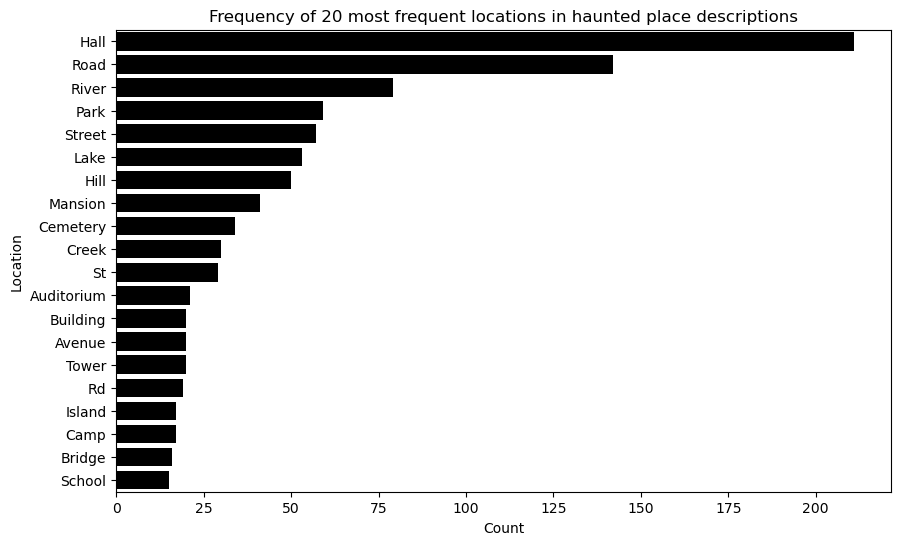

In [102]:
plt.figure(figsize=(10,6))
sns.barplot(x=[t[1] for t in freq_places], y=[t[0] for t in freq_places], color="black")
plt.title("Frequency of 20 most frequent locations in haunted place descriptions")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

Why do you suppose some of these places are more haunted than others?

**Your response**: These places are more haunted than others likely because people simply go to these places (public spots or indoor settings common in houses or apartments) more often than others, increasing likelyhood of haunted encounters. Additionally, the top places displayed here are more likely to be frequented at night, whether it be people driving, moving around their places of living, or walking around in public spaces. Some locations, like cemeteries, are already spooky due to their macabre nature. 

#### Question 4

In your opinion, what is the scariest haunting in Eugene?

**Your response**: Pacific Hall

# Submission

**That's a wrap!** I hope this exam didn't jump scare you.

Be sure to check that all of your tests pass the autograder.

In [103]:
grader.check_all()

q1_1 results: All test cases passed!

q1_2 results: All test cases passed!

q1_3 results: All test cases passed!

q1_4 results: All test cases passed!

q2_2 results: All test cases passed!

q2_6 results: All test cases passed!

q2_8 results: All test cases passed!

q2_9 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

Make sure you have run all cells in your notebook in order. Then execute the following in the File menu

* Save and Checkpoint
* Close and Halt

Then upload your notebook to Canvas Assignment Midterm.